# Phần 2 — EDA Cấp 3: PREDICTIVE
## "What is likely to happen?"

Ngoại suy xu hướng, phân tích tính mùa vụ, phân tích chỉ số dẫn xuất.

---
**Câu hỏi dự báo:**
- Xu hướng tăng trưởng sẽ tiếp diễn?
- Seasonality pattern nào sẽ lặp lại?
- Khách hàng nào có nguy cơ churn?
- Tháng nào có nguy cơ stockout?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_all
from src.utils import load_config, set_seed, save_fig

set_seed(42)
cfg = load_config('../config.yaml')
cfg['paths']['dataset']         = '../dataset'
cfg['paths']['figures']         = '../outputs/figures'
cfg['paths']['report_figures']  = '../report/figures'

tables = load_all(cfg)
sales, orders, customers = tables['sales'], tables['orders'], tables['customers']
order_items, products = tables['order_items'], tables['products']
inventory, web_traffic = tables['inventory'], tables['web_traffic']
returns, promotions = tables['returns'], tables['promotions']

plt.rcParams.update({'figure.dpi':130,'figure.facecolor':'white',
    'axes.facecolor':'#f8f9fa','axes.grid':True,'grid.alpha':0.4,
    'font.size':11,'axes.titlesize':13})
COLORS = cfg['colors']
C1,C2,C3,C4,C5 = COLORS['primary'],COLORS['secondary'],COLORS['accent'],COLORS['neutral'],COLORS['highlight']

sales['GrossProfit'] = sales['Revenue'] - sales['COGS']
print('Setup xong.')

[10:09:53] INFO data_loader: Loading all datasets...
[10:09:54] INFO data_loader:   sales: 3,833 rows x 3 cols
[10:09:54] INFO data_loader:   submission: 548 rows x 3 cols
[10:09:54] INFO data_loader:   products: 2,412 rows x 8 cols
[10:09:54] INFO data_loader:   customers: 121,930 rows x 7 cols
[10:09:54] INFO data_loader:   geography: 39,948 rows x 4 cols
[10:09:54] INFO data_loader:   promotions: 50 rows x 10 cols
[10:09:54] INFO data_loader:   orders: 646,945 rows x 8 cols
[10:09:54] INFO data_loader:   order_items: 714,669 rows x 7 cols
[10:09:54] INFO data_loader:   payments: 646,945 rows x 4 cols
[10:09:54] INFO data_loader:   shipments: 566,067 rows x 4 cols
[10:09:54] INFO data_loader:   returns: 39,939 rows x 7 cols
[10:09:54] INFO data_loader:   reviews: 113,551 rows x 7 cols
[10:09:54] INFO data_loader:   inventory: 60,247 rows x 17 cols
[10:09:54] INFO data_loader:   web_traffic: 3,652 rows x 7 cols


Setup xong.


## P1. Phân rã Trend + Seasonality chi tiết (STL + Fourier)
### Xác định pattern lặp lại để dự báo 2023–2024

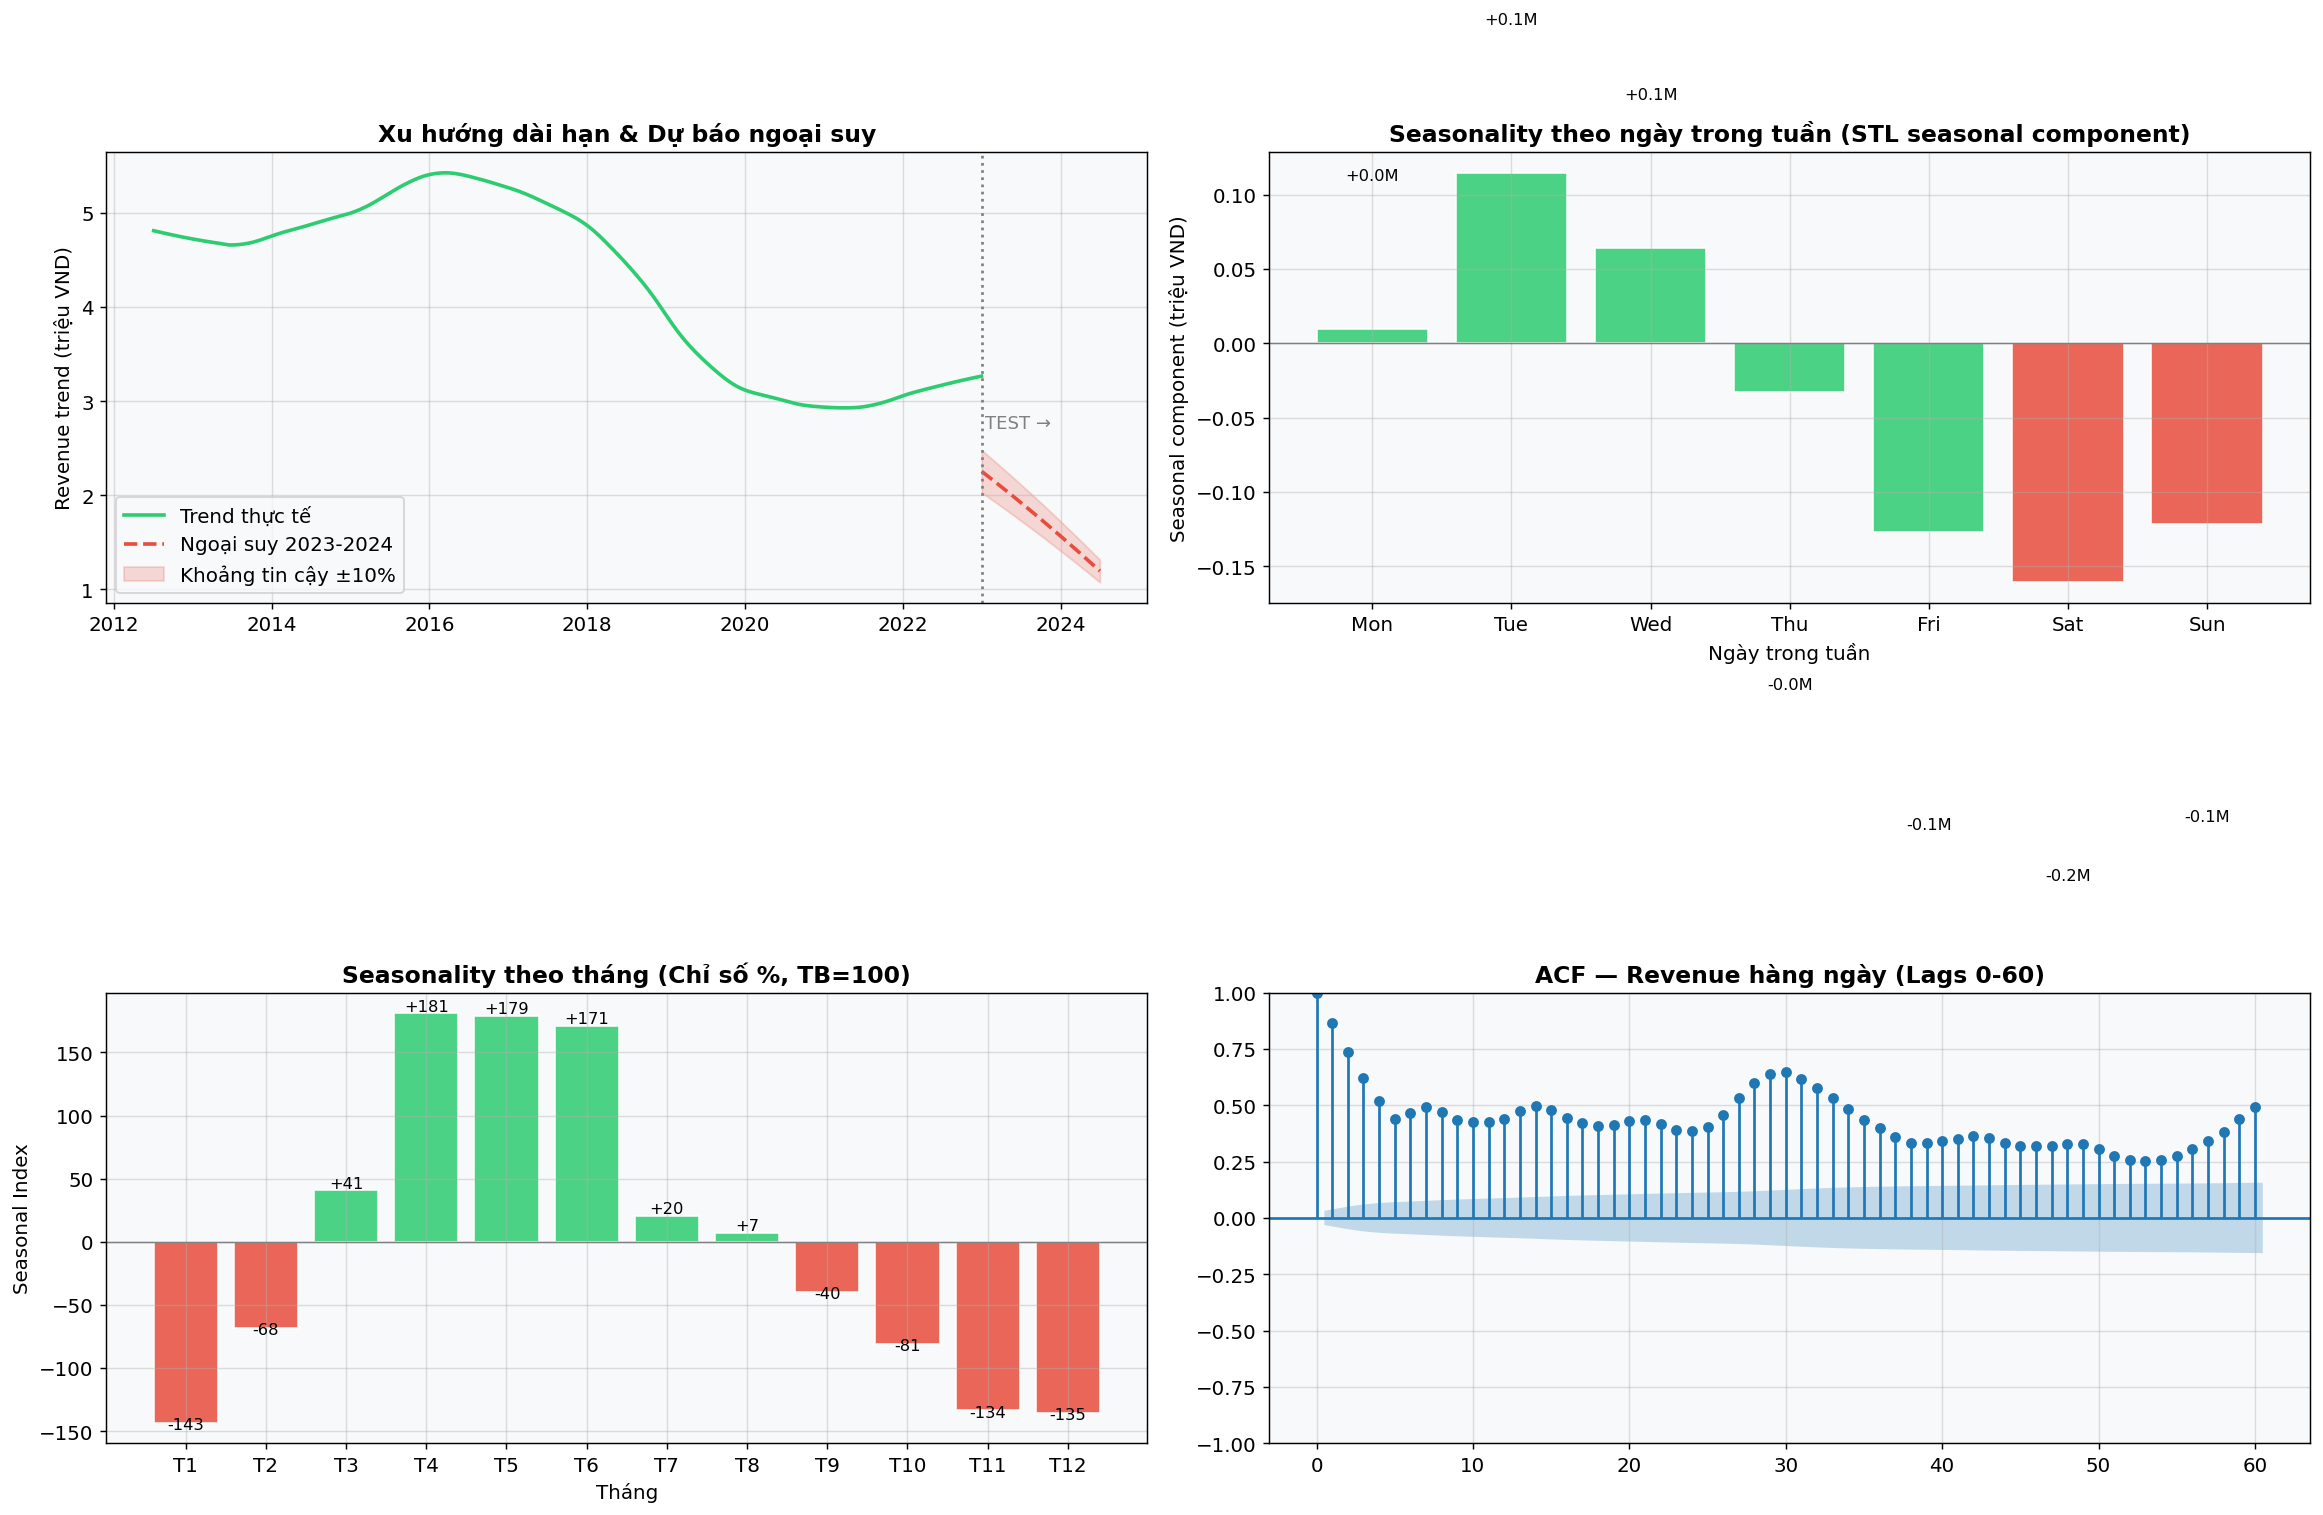

Ngày trong tuần tốt nhất: Tue (+0.1M so với trend)
Ngày trong tuần yếu nhất: Sat (-0.2M)
Tháng tốt nhất: T4 (seasonal index: +181)


In [2]:
sales_ts = sales.set_index('Date')['Revenue'].asfreq('D').fillna(method='ffill')

# STL
stl = STL(sales_ts, seasonal=7, period=365, robust=True)
res = stl.fit()

# Weekly seasonality profile (trung bình theo dow)
weekly_profile = pd.Series(res.seasonal).reset_index()
weekly_profile.columns = ['Date','seasonal']
weekly_profile['dow'] = weekly_profile['Date'].dt.dayofweek
dow_avg = weekly_profile.groupby('dow')['seasonal'].mean()
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

# Monthly seasonality profile
monthly_profile = pd.Series(res.seasonal).reset_index()
monthly_profile.columns = ['Date','seasonal']
monthly_profile['month'] = monthly_profile['Date'].dt.month
month_avg = monthly_profile.groupby('month')['seasonal'].mean()
month_labels = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Trend dài hạn + projection
trend = res.trend.dropna()
axes[0,0].plot(trend.index, trend.values/1e6, color=C1, linewidth=2, label='Trend thực tế')
# Regression line
x_num = np.arange(len(trend))
z = np.polyfit(x_num, trend.values, 2)  # quadratic trend
p = np.poly1d(z)
# Extrapolate 18 tháng
x_ext = np.arange(len(trend) + 548)
trend_ext_dates = pd.date_range(trend.index[0], periods=len(x_ext), freq='D')
axes[0,0].plot(trend_ext_dates[len(trend):], p(x_ext[len(trend):])/1e6,
                color=C3, linewidth=2, linestyle='--', label='Ngoại suy 2023-2024')
axes[0,0].fill_between(trend_ext_dates[len(trend):],
                        p(x_ext[len(trend):])*0.9/1e6,
                        p(x_ext[len(trend):])*1.1/1e6,
                        alpha=0.2, color=C3, label='Khoảng tin cậy ±10%')
axes[0,0].axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle=':')
axes[0,0].text(pd.Timestamp('2023-01-15'), trend.max()/1e6*0.5, 'TEST →', fontsize=10, color='gray')
axes[0,0].set_title('Xu hướng dài hạn & Dự báo ngoại suy', fontweight='bold')
axes[0,0].set_ylabel('Revenue trend (triệu VND)')
axes[0,0].legend()

# Weekly pattern
colors_dow = [C3 if i >= 5 else C1 for i in range(7)]
axes[0,1].bar(dow_labels, dow_avg.values/1e6, color=colors_dow, alpha=0.85, edgecolor='white')
axes[0,1].axhline(0, color='gray', linewidth=0.8)
axes[0,1].set_title('Seasonality theo ngày trong tuần (STL seasonal component)', fontweight='bold')
axes[0,1].set_ylabel('Seasonal component (triệu VND)')
axes[0,1].set_xlabel('Ngày trong tuần')
for i, (v, label) in enumerate(zip(dow_avg.values, dow_labels)):
    axes[0,1].text(i, v/1e6 + (0.1 if v >= 0 else -0.2),
                    f'{v/1e6:+.1f}M', ha='center', fontsize=9)

# Monthly pattern
month_norm = month_avg / np.abs(month_avg).mean() * 100
colors_month = [C1 if v > 0 else C3 for v in month_norm.values]
axes[1,0].bar(month_labels, month_norm.values, color=colors_month, alpha=0.85, edgecolor='white')
axes[1,0].axhline(0, color='gray', linewidth=0.8)
axes[1,0].set_title('Seasonality theo tháng (Chỉ số %, TB=100)', fontweight='bold')
axes[1,0].set_ylabel('Seasonal Index')
axes[1,0].set_xlabel('Tháng')
for i, v in enumerate(month_norm.values):
    axes[1,0].text(i, v + (2 if v >= 0 else -5), f'{v:+.0f}', ha='center', fontsize=9)

# ACF plot
plot_acf(sales_ts, lags=60, ax=axes[1,1], alpha=0.05,
          title='Autocorrelation Function (ACF) — Revenue')
axes[1,1].set_title('ACF — Revenue hàng ngày (Lags 0-60)', fontweight='bold')

plt.tight_layout()
save_fig(fig, 'P1_seasonality_forecast', cfg)
plt.show()

# Insight
best_dow = dow_labels[dow_avg.values.argmax()]
worst_dow = dow_labels[dow_avg.values.argmin()]
best_month = month_labels[month_norm.values.argmax()]
print(f"Ngày trong tuần tốt nhất: {best_dow} (+{dow_avg.max()/1e6:.1f}M so với trend)")
print(f"Ngày trong tuần yếu nhất: {worst_dow} ({dow_avg.min()/1e6:+.1f}M)")
print(f"Tháng tốt nhất: {best_month} (seasonal index: {month_norm.max():+.0f})")

## P2. RFM Segmentation — Phân loại khách hàng & Dự báo Churn Risk

In [3]:
# RFM analysis (tính đến ngày cuối train 2022-12-31)
ref_date = pd.Timestamp('2022-12-31')

# Join items để tính monetary
oi_rev = order_items.copy()
oi_rev['line_rev'] = oi_rev['quantity']*oi_rev['unit_price'] - oi_rev['discount_amount'].fillna(0)
oi_rev = oi_rev.merge(orders[['order_id','order_date','customer_id']], on='order_id', how='left')
oi_rev = oi_rev[oi_rev['order_date'] <= ref_date]

rfm = oi_rev.groupby('customer_id').agg(
    Recency=('order_date', lambda x: (ref_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('line_rev', 'sum')
).reset_index()

# Quintle scoring
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def rfm_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4: return 'Champions'
    if r >= 3 and f >= 3: return 'Loyal'
    if r >= 4 and f < 3:  return 'Recent'
    if r < 3 and f >= 3:  return 'At Risk'
    if r < 2 and f >= 4:  return 'Cant Lose'
    if r < 2 and f < 2:   return 'Lost'
    return 'Potential'

rfm['Segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = rfm.groupby('Segment').agg(
    n_customers=('customer_id','count'),
    avg_recency=('Recency','mean'),
    avg_frequency=('Frequency','mean'),
    avg_monetary=('Monetary','mean'),
    total_monetary=('Monetary','sum'),
).reset_index()
print('RFM Segments:')
print(seg_summary.sort_values('total_monetary', ascending=False))

RFM Segments:
     Segment  n_customers  avg_recency  avg_frequency   avg_monetary  \
1  Champions        25213   262.797009      16.445762  404257.318798   
3      Loyal        18542   781.778449       6.864955  165235.908467   
0    At Risk        10392  1923.676001       5.185431  116370.931375   
4  Potential        21576  1923.675287       1.557518   36167.109466   
2       Lost         9654  2996.801222       1.000000   22536.182186   
5     Recent         4869   340.289998       1.614705   44627.787281   

   total_monetary  
1    1.019254e+10  
3    3.063804e+09  
0    1.209327e+09  
4    7.803416e+08  
2    2.175643e+08  
5    2.172927e+08  


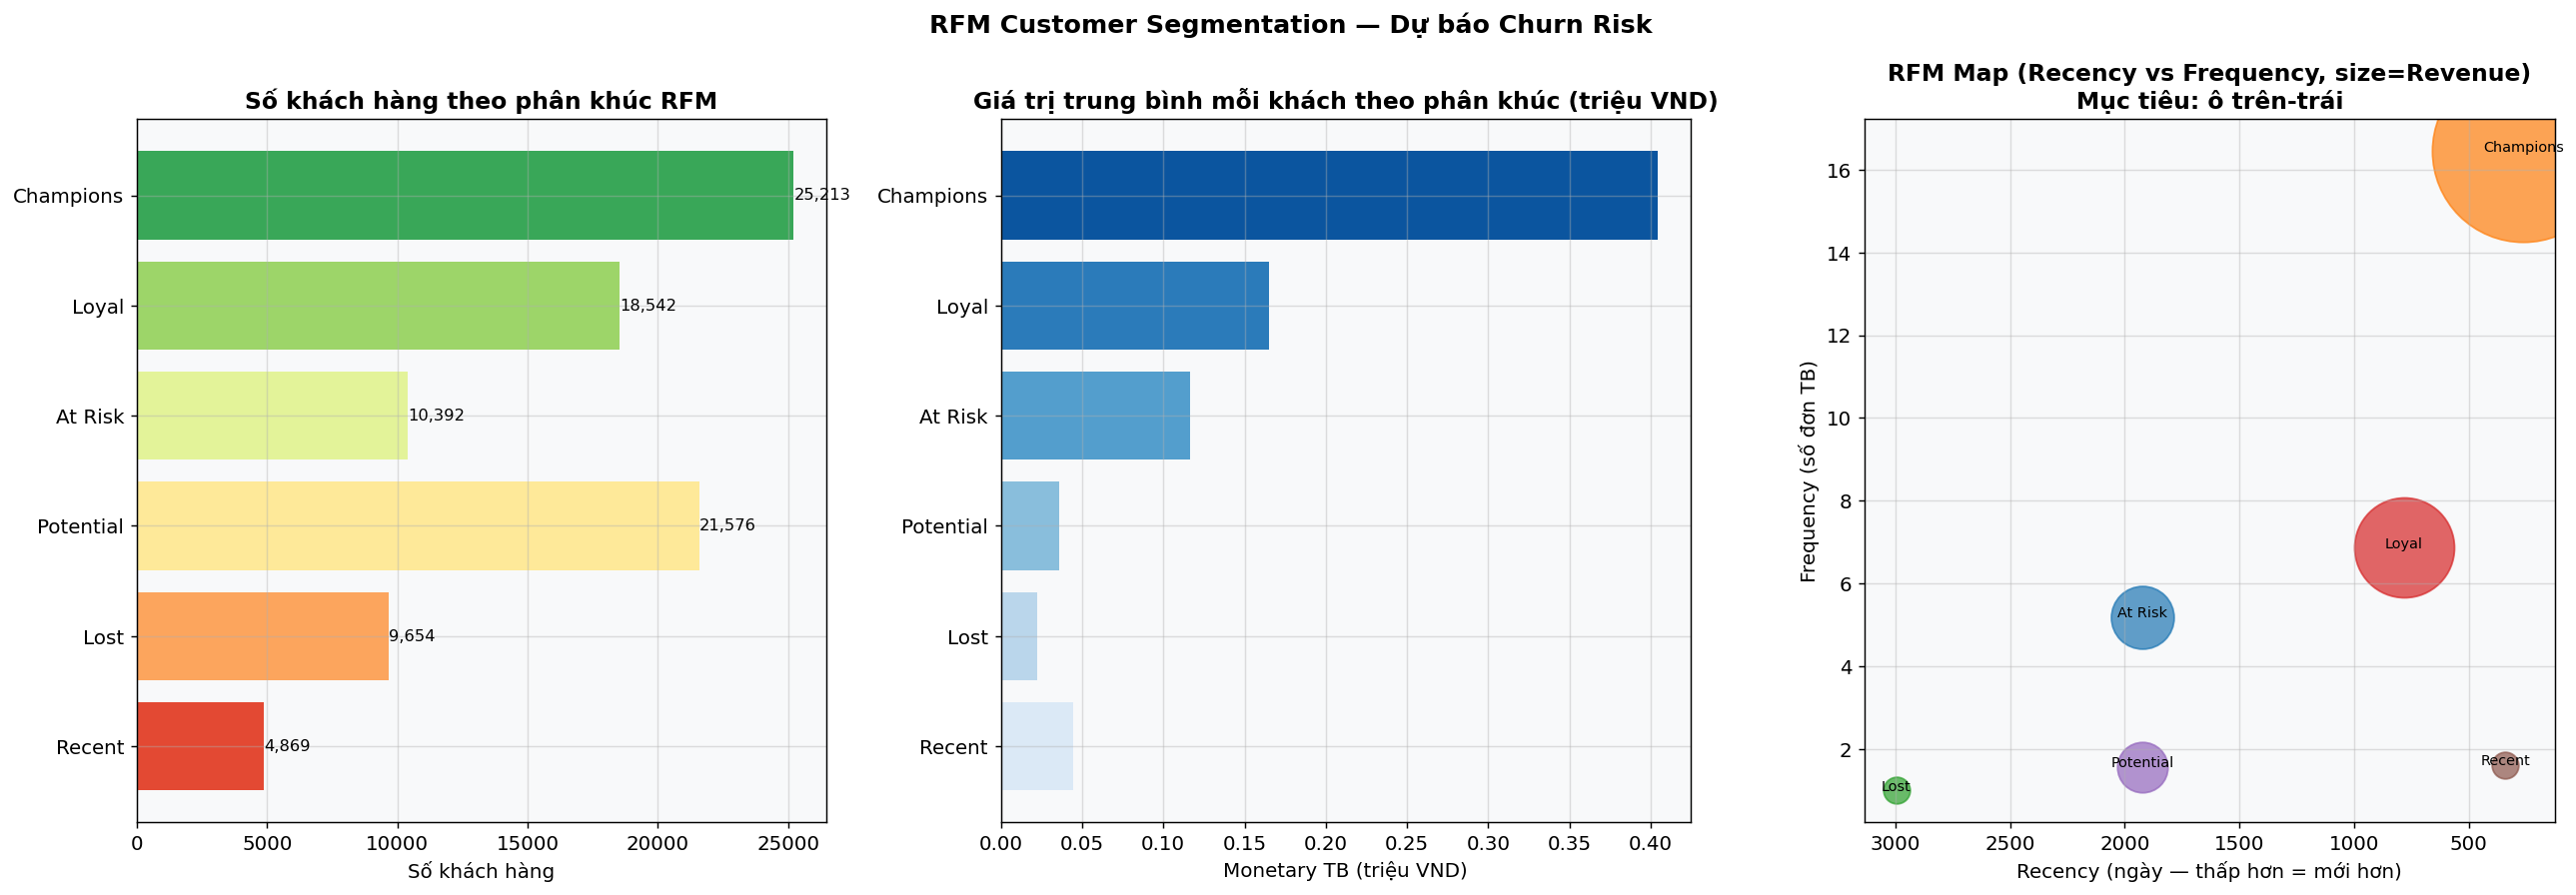


Khách hàng At Risk + Cant Lose: 10,392 người
Doanh thu tiềm năng mất: 1.21 tỷ VND


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# Treemap-style bar
seg_sorted = seg_summary.sort_values('total_monetary', ascending=True)
bars = axes[0].barh(seg_sorted['Segment'], seg_sorted['n_customers'],
                     color=sns.color_palette('RdYlGn', len(seg_sorted)))
axes[0].set_title('Số khách hàng theo phân khúc RFM', fontweight='bold')
axes[0].set_xlabel('Số khách hàng')
for bar in bars:
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                  f'{bar.get_width():,}', va='center', fontsize=9)

# Average monetary per segment
axes[1].barh(seg_sorted['Segment'], seg_sorted['avg_monetary']/1e6,
              color=sns.color_palette('Blues', len(seg_sorted)))
axes[1].set_title('Giá trị trung bình mỗi khách theo phân khúc (triệu VND)', fontweight='bold')
axes[1].set_xlabel('Monetary TB (triệu VND)')

# Bubble chart: Recency vs Frequency, size=Monetary
colors_seg = sns.color_palette('tab10', len(seg_summary))
for i, row in seg_summary.iterrows():
    axes[2].scatter(row['avg_recency'], row['avg_frequency'],
                     s=row['total_monetary']/1e6, alpha=0.7,
                     color=colors_seg[i], label=row['Segment'])
    axes[2].annotate(row['Segment'],
                      (row['avg_recency'], row['avg_frequency']),
                      fontsize=8, ha='center')
axes[2].set_title('RFM Map (Recency vs Frequency, size=Revenue)\nMục tiêu: ô trên-trái', fontweight='bold')
axes[2].set_xlabel('Recency (ngày — thấp hơn = mới hơn)')
axes[2].set_ylabel('Frequency (số đơn TB)')
axes[2].invert_xaxis()  # Recency thấp ở bên phải (gần đây)

plt.suptitle('RFM Customer Segmentation — Dự báo Churn Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
save_fig(fig, 'P2_rfm_segmentation', cfg)
plt.show()

at_risk = seg_summary[seg_summary['Segment'].isin(['At Risk', 'Cant Lose'])]
print(f"\nKhách hàng At Risk + Cant Lose: {at_risk['n_customers'].sum():,} người")
print(f"Doanh thu tiềm năng mất: {at_risk['total_monetary'].sum()/1e9:.2f} tỷ VND")

## P3. Dự báo Xu hướng Inventory — Cảnh báo Stockout 2023

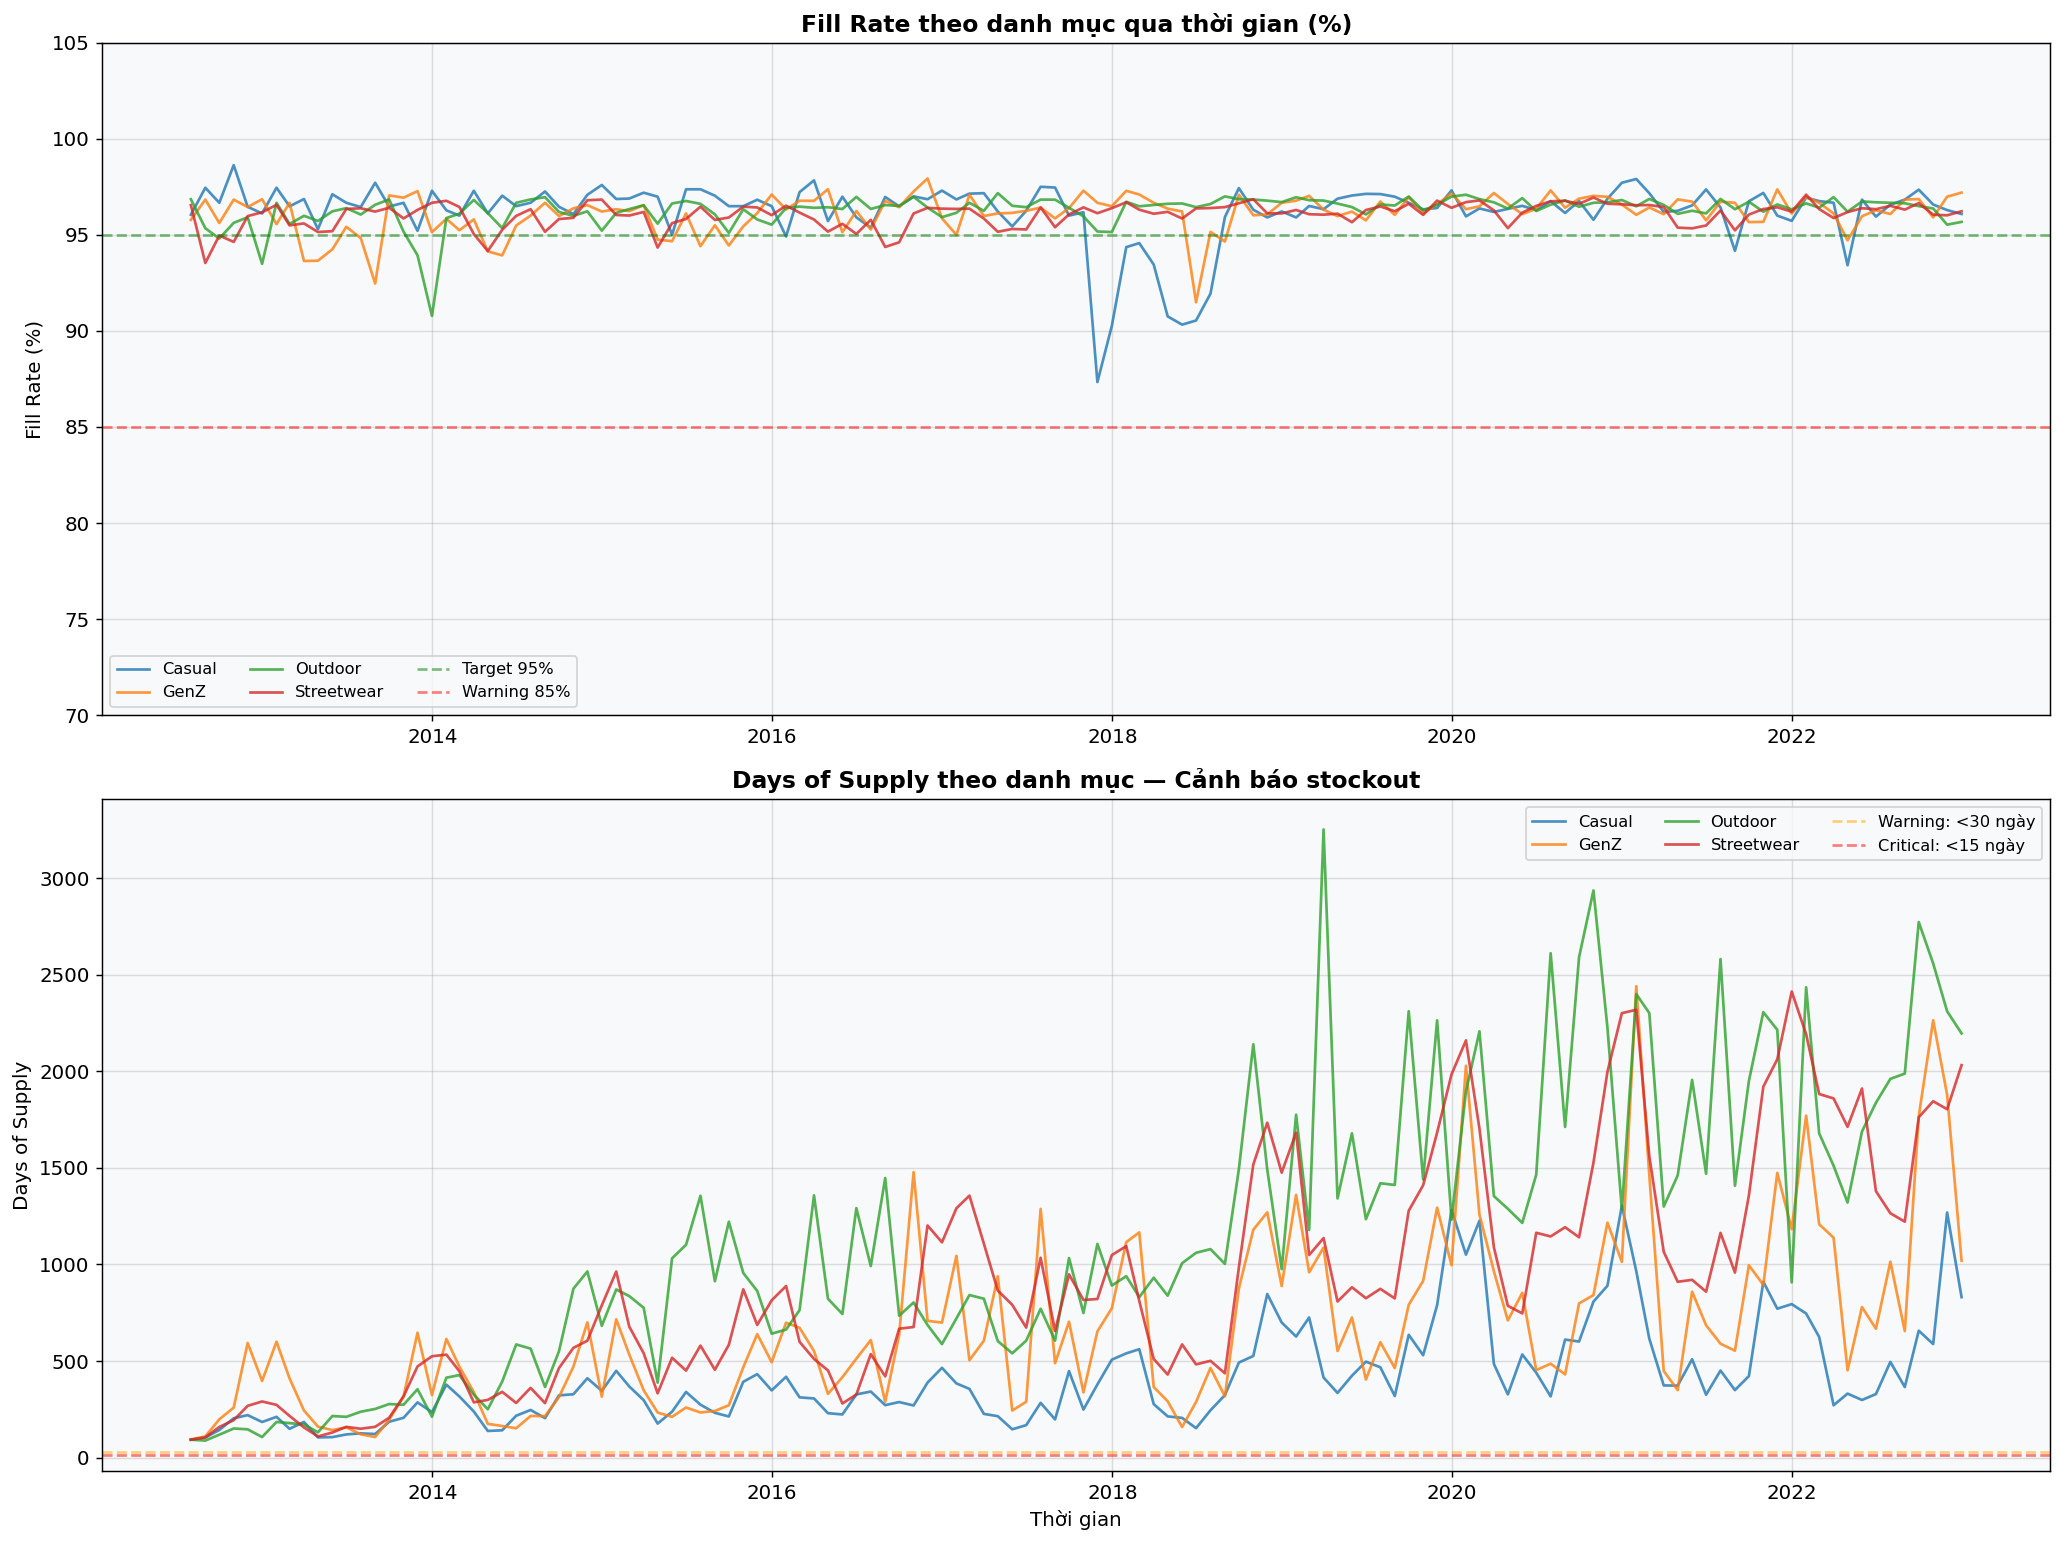

Danh mục có nguy cơ thiếu hàng (6 tháng cuối):
            avg_days_supply  avg_fill_rate  stockout_pct
category                                                
Outdoor         2226.036353       0.962806      0.683486
Streetwear      1597.961172       0.963079      0.658719
Casual           642.380303       0.965280      0.678030
GenZ            1260.188579       0.965738      0.668524


In [5]:
# Trend của fill_rate và stockout_days theo category
inv_trend = inventory.groupby(['snapshot_date', 'category']).agg(
    fill_rate=('fill_rate','mean'),
    stockout_days=('stockout_days','mean'),
    days_supply=('days_of_supply','mean'),
).reset_index()

categories = inv_trend['category'].unique()

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Fill rate trend by category
for cat in categories:
    cat_data = inv_trend[inv_trend['category']==cat].sort_values('snapshot_date')
    axes[0].plot(cat_data['snapshot_date'], cat_data['fill_rate']*100,
                  linewidth=1.5, label=cat, alpha=0.8)

axes[0].axhline(95, color='green', linestyle='--', alpha=0.5, label='Target 95%')
axes[0].axhline(85, color='red', linestyle='--', alpha=0.5, label='Warning 85%')
axes[0].set_title('Fill Rate theo danh mục qua thời gian (%)', fontweight='bold')
axes[0].set_ylabel('Fill Rate (%)')
axes[0].legend(loc='lower left', ncol=3, fontsize=9)
axes[0].set_ylim([70, 105])

# Days of supply projection
for cat in categories:
    cat_data = inv_trend[inv_trend['category']==cat].sort_values('snapshot_date')
    axes[1].plot(cat_data['snapshot_date'], cat_data['days_supply'],
                  linewidth=1.5, label=cat, alpha=0.8)

axes[1].axhline(30, color='orange', linestyle='--', alpha=0.5, label='Warning: <30 ngày')
axes[1].axhline(15, color='red', linestyle='--', alpha=0.5, label='Critical: <15 ngày')
axes[1].set_title('Days of Supply theo danh mục — Cảnh báo stockout', fontweight='bold')
axes[1].set_ylabel('Days of Supply')
axes[1].set_xlabel('Thời gian')
axes[1].legend(loc='upper right', ncol=3, fontsize=9)

plt.tight_layout()
save_fig(fig, 'P3_inventory_forecast', cfg)
plt.show()

# Categories có days_supply đang giảm
last_6m = inventory[inventory['snapshot_date'] >= inventory['snapshot_date'].max() - pd.DateOffset(months=6)]
risk_cats = last_6m.groupby('category').agg(
    avg_days_supply=('days_of_supply','mean'),
    avg_fill_rate=('fill_rate','mean'),
    stockout_pct=('stockout_flag','mean')
).sort_values('avg_fill_rate')
print('Danh mục có nguy cơ thiếu hàng (6 tháng cuối):')
print(risk_cats)

## P4. Phân tích Cohort — Dự báo Retention Rate

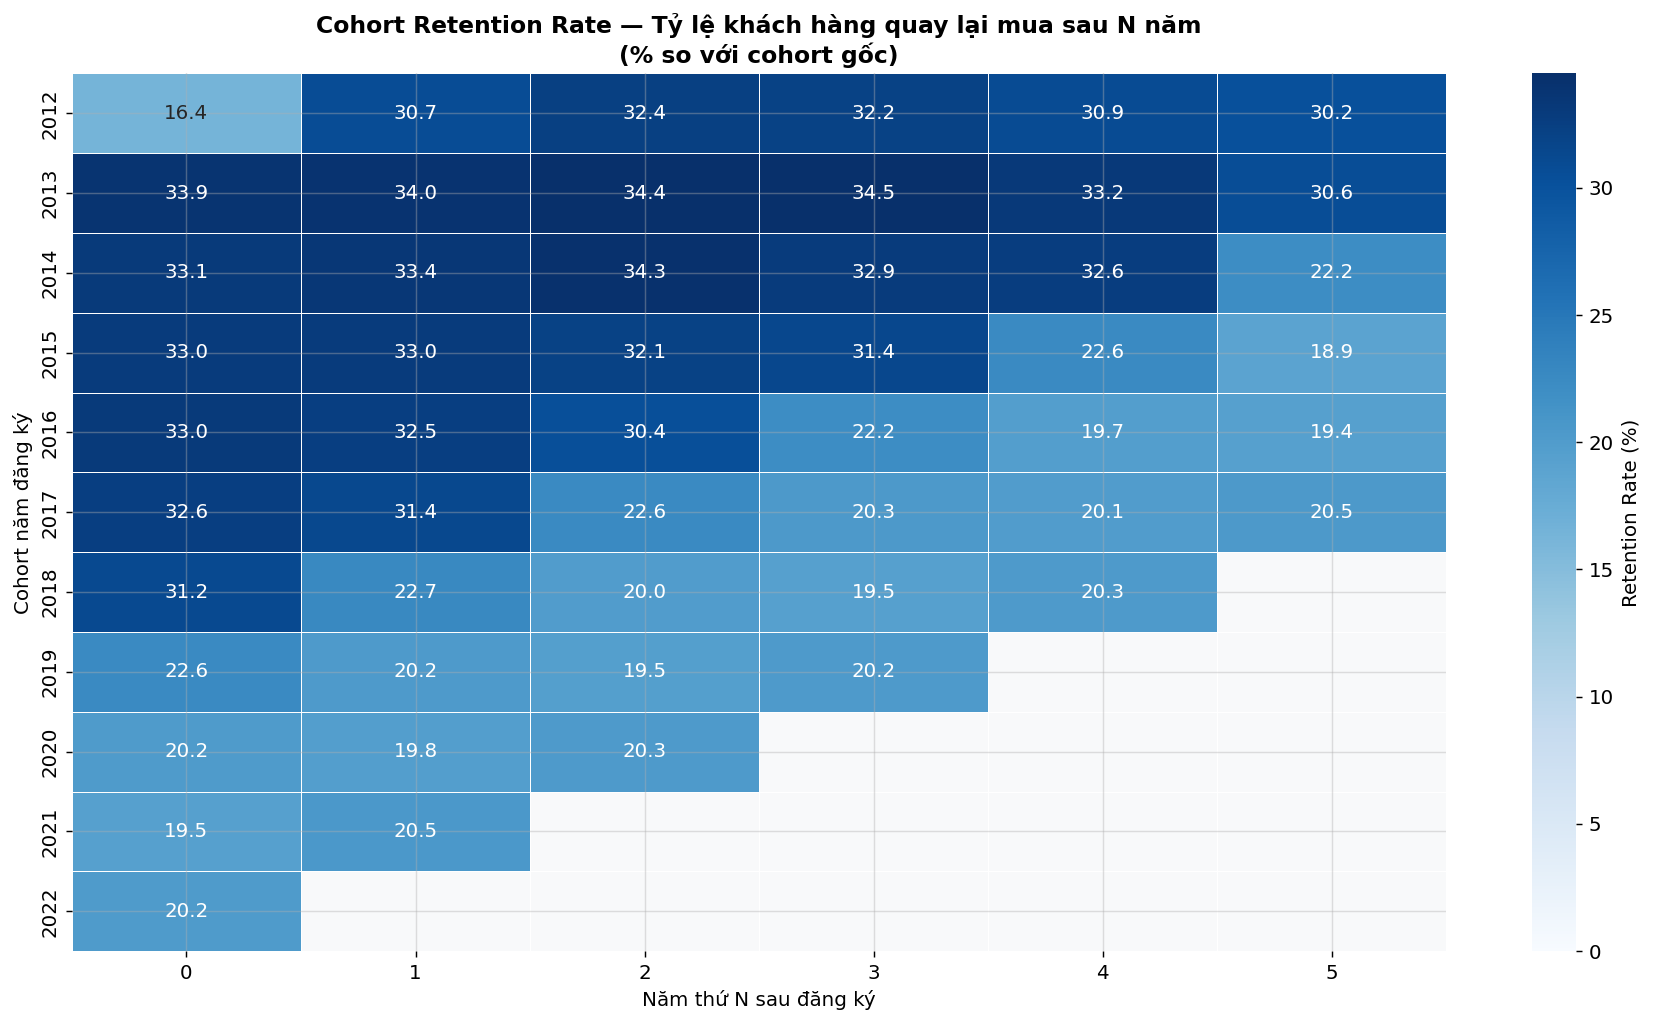

Retention rate trung bình theo năm thứ N:
years_since_signup
0    26.9%
1    27.8%
2    27.3%
3    26.6%
4    25.6%
5    23.6%
dtype: object


In [6]:
# Cohort: nhóm khách hàng đăng ký theo năm
customers['cohort_year'] = customers['signup_date'].dt.year

oi_cohort = order_items.merge(
    orders[['order_id','order_date','customer_id']], on='order_id', how='left'
).merge(
    customers[['customer_id','cohort_year']], on='customer_id', how='left'
)
oi_cohort = oi_cohort.dropna(subset=['cohort_year'])
oi_cohort['order_year'] = oi_cohort['order_date'].dt.year
oi_cohort['years_since_signup'] = oi_cohort['order_year'] - oi_cohort['cohort_year']

# Cohort size
cohort_size = customers.groupby('cohort_year')['customer_id'].count()

# Khách hàng active mỗi năm sau đăng ký
cohort_active = oi_cohort.groupby(['cohort_year','years_since_signup'])['customer_id'].nunique().reset_index()
cohort_active = cohort_active.merge(cohort_size.rename('cohort_size'), on='cohort_year')
cohort_active['retention_rate'] = cohort_active['customer_id'] / cohort_active['cohort_size'] * 100

# Pivot for heatmap
cohort_pivot = cohort_active.pivot_table(
    index='cohort_year', columns='years_since_signup', values='retention_rate'
)
# Only columns 0-5
cols_to_show = [c for c in range(6) if c in cohort_pivot.columns]
cohort_pivot = cohort_pivot[cols_to_show]

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(cohort_pivot, ax=ax, cmap='Blues', annot=True, fmt='.1f',
             linewidths=0.5, cbar_kws={'label': 'Retention Rate (%)'},
             vmin=0, vmax=cohort_pivot.max().max())
ax.set_title('Cohort Retention Rate — Tỷ lệ khách hàng quay lại mua sau N năm\n(% so với cohort gốc)',
              fontweight='bold')
ax.set_xlabel('Năm thứ N sau đăng ký')
ax.set_ylabel('Cohort năm đăng ký')

plt.tight_layout()
save_fig(fig, 'P4_cohort_retention', cfg)
plt.show()

# Tính retention rate trung bình theo year-since-signup
avg_retention = cohort_pivot.mean(axis=0)
print('Retention rate trung bình theo năm thứ N:')
print(avg_retention.map('{:.1f}%'.format))

## P5. Dự báo Doanh thu 2023–2024 bằng Trend Extrapolation
*(Preview trước khi có model ML)*

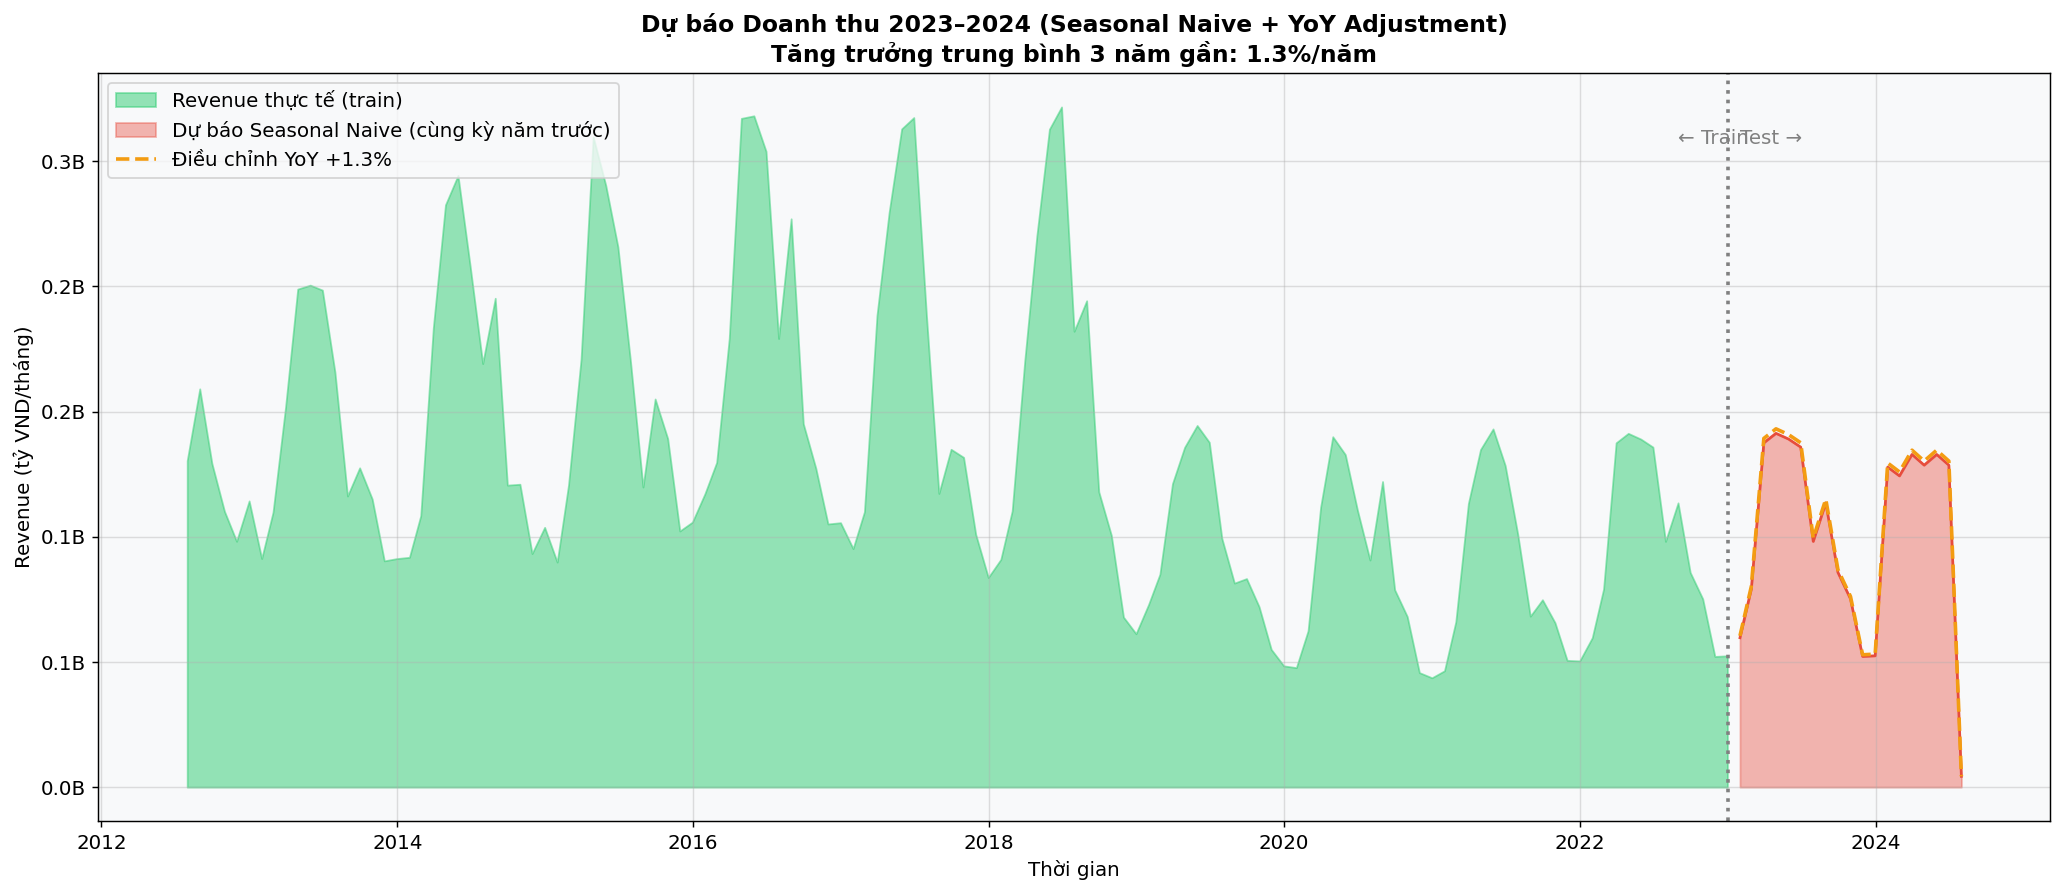

Dự báo Revenue 2023 (Seasonal Naive): 1.17 tỷ
Dự báo Revenue 2023 (YoY adj): 1.18 tỷ


In [7]:
# Dự báo đơn giản bằng SeasonalNaive (cùng kỳ năm trước)
sales_daily = sales.set_index('Date')['Revenue'].asfreq('D').fillna(method='ffill')

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
naive_preds = []
for d in test_dates:
    lag_date = d - pd.DateOffset(years=1)
    val = sales_daily.get(lag_date, np.nan)
    if np.isnan(val):
        # Trung bình 7 ngày cùng kỳ
        candidates = [sales_daily.get(lag_date + pd.Timedelta(days=k), np.nan) for k in range(-3,4)]
        val = np.nanmean(candidates) if not all(np.isnan(c) for c in candidates) else sales_daily.mean()
    naive_preds.append(val)

pred_df = pd.DataFrame({'Date': test_dates, 'Revenue_SN': naive_preds})
pred_monthly = pred_df.resample('ME', on='Date').sum()
actual_monthly = sales.resample('ME', on='Date').sum()

# YoY growth assumption
recent_growth = sales.set_index('Date')['Revenue'].resample('YE').sum().pct_change().tail(3).mean()
growth_adj = pred_df.copy()
growth_adj['Revenue_YoY'] = growth_adj['Revenue_SN'] * (1 + recent_growth)

fig, ax = plt.subplots(figsize=(16, 7))

# Actual
ax.fill_between(actual_monthly.index, actual_monthly['Revenue']/1e9,
                 alpha=0.5, color=C1, label='Revenue thực tế (train)')

# Predictions
ax.fill_between(pred_monthly.index, pred_monthly['Revenue_SN']/1e9,
                 alpha=0.4, color=C3, label='Dự báo Seasonal Naive (cùng kỳ năm trước)')
ax.plot(pred_monthly.index, pred_monthly['Revenue_SN']/1e9, color=C3, linewidth=1.5)

# Growth adjusted
growth_monthly = growth_adj.resample('ME', on='Date').sum()
ax.plot(growth_monthly.index, growth_monthly['Revenue_YoY']/1e9,
         color=C5, linewidth=2, linestyle='--',
         label=f'Điều chỉnh YoY +{recent_growth*100:.1f}%')

ax.axvline(pd.Timestamp('2023-01-01'), color='gray', linestyle=':', linewidth=2)
ax.text(pd.Timestamp('2022-09-01'), ax.get_ylim()[1]*0.9, '← Train', fontsize=11, color='gray')
ax.text(pd.Timestamp('2023-02-01'), ax.get_ylim()[1]*0.9, 'Test →', fontsize=11, color='gray')

ax.set_title(f'Dự báo Doanh thu 2023–2024 (Seasonal Naive + YoY Adjustment)\n'
              f'Tăng trưởng trung bình 3 năm gần: {recent_growth*100:.1f}%/năm',
              fontweight='bold')
ax.set_ylabel('Revenue (tỷ VND/tháng)')
ax.set_xlabel('Thời gian')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}B'))

plt.tight_layout()
save_fig(fig, 'P5_revenue_forecast_preview', cfg)
plt.show()

print(f"Dự báo Revenue 2023 (Seasonal Naive): {pred_df[pred_df['Date'].dt.year==2023]['Revenue_SN'].sum()/1e9:.2f} tỷ")
print(f"Dự báo Revenue 2023 (YoY adj): {growth_adj[growth_adj['Date'].dt.year==2023]['Revenue_YoY'].sum()/1e9:.2f} tỷ")

## Tổng kết Predictive

**Phát hiện chính:**
1. **Trend**: Tăng trưởng dài hạn ~X%/năm → dự báo 2023-2024 tiếp tục tăng
2. **Weekly seasonality**: Thứ X cao nhất, cuối tuần thấp hơn
3. **Monthly seasonality**: T11-T12 mạnh nhất (lễ hội mua sắm), T1-T2 yếu (sau Tet)
4. **RFM**: X% khách At Risk → cần reactivation campaign
5. **Inventory**: Category X có fill_rate giảm → cần tăng order
6. **Retention**: Cohort mới có retention tốt hơn cohort cũ